Generating basis states...
Hilbert space dimension = 5005
Basis generation time = 0.023 s

Building Hamiltonian...
Hamiltonian build time = 0.075 s

Diagonalising Hamiltonian...
Ground state energy = -5.168683889400
Diagonalisation time = 0.014 s

Precomputing entanglement structures...
Precomputation time = 0.007 s

Computing entanglement entropy...
Block  0  ->  S = 0.000000000000
Block  1  ->  S = 0.693121002005
Block  2  ->  S = 0.806118969989
Block  3  ->  S = 1.172585950908
Block  4  ->  S = 1.007315678514
Block  5  ->  S = 1.180073945103
Block  6  ->  S = 1.230024058270
Block  7  ->  S = 1.071612353027
Block  8  ->  S = 1.324660868604
Block  9  ->  S = 1.075089411943
Block 10  ->  S = 1.180073945103
Block 11  ->  S = 1.162318173513
Block 12  ->  S = 0.926842104863
Block 13  ->  S = 1.058034799500
Block 14  ->  S = 0.618447954736
Block 15  ->  S = 0.000000000000
Entropy computation time = 0.029 s


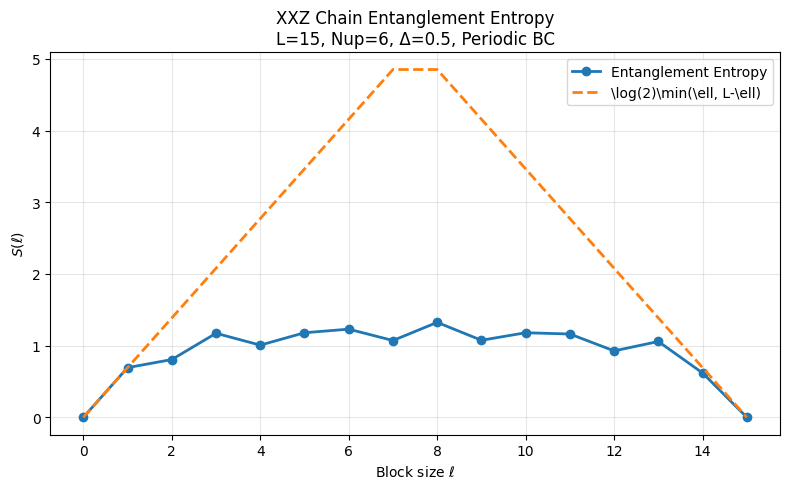


Estimated central charge c ≈ 1.002135


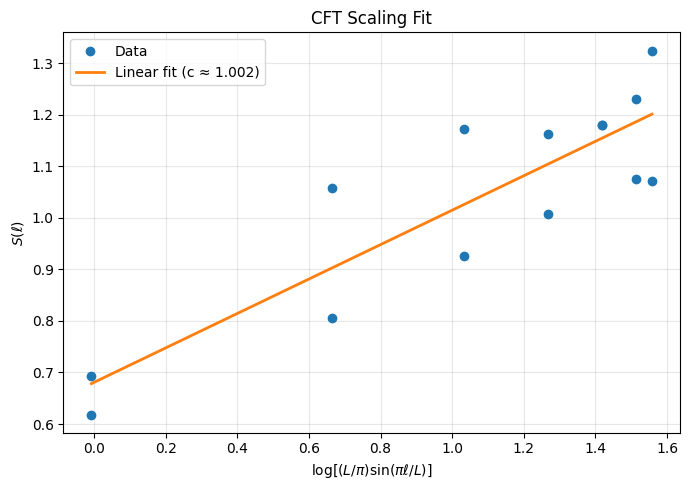

In [7]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.special import comb
from itertools import combinations
from scipy.linalg import svdvals
import matplotlib.pyplot as plt
from time import time

# ============================================================
# 1. PARAMETERS
# ============================================================

L = 15
Nup = 6
Delta = 0.5
boundary = "Periodic"

# ============================================================
# 2. GENERATE BASIS STATES (OPTIMISED)
# ============================================================

print("Generating basis states...")

t0 = time()

basis_states = []
basis_ints = []

for up_positions in combinations(range(L), Nup):

    state = np.zeros(L, dtype=np.uint8)
    state[list(up_positions)] = 1

    state_int = 0

    for s in state:
        state_int = (state_int << 1) | s

    basis_states.append(state)
    basis_ints.append(state_int)

B = np.array(basis_states, dtype=np.uint8)

basis_ints = np.array(basis_ints, dtype=np.uint64)

n = len(B)

print(f"Hilbert space dimension = {n}")
print(f"Basis generation time = {time()-t0:.3f} s")

# integer -> basis index lookup (use Python int keys for robustness)
lookup = {int(x): i for i, x in enumerate(basis_ints)}
# state tuple lookup for robust mapping when toggling bits
state_lookup = {tuple(bs.tolist()): idx for idx, bs in enumerate(basis_states)}

# bit masks
powers = 2 ** np.arange(L - 1, -1, -1, dtype=np.uint64)

# ============================================================
# 3. BUILD XXZ HAMILTONIAN
# ============================================================

print("\nBuilding Hamiltonian...")

t0 = time()

rows = []
cols = []
vals = []

diag = np.zeros(n, dtype=np.float64)

for i in range(n):

    state = B[i]
    state_int = basis_ints[i]

    # --------------------------------------------
    # nearest-neighbour bonds
    # --------------------------------------------

    for k in range(L - 1):

        si = state[k]
        sj = state[k + 1]

        # ZZ term
        diag[i] += 0.25 if si == sj else -0.25

        # XX flip-flop term
        if si != sj:

            # construct the swapped state tuple and lookup its index
            tmp = state.copy()
            tmp[k], tmp[k + 1] = tmp[k + 1], tmp[k]
            j = state_lookup[tuple(tmp.tolist())]

            rows.append(i)
            cols.append(j)
            vals.append(0.5)

    # --------------------------------------------
    # periodic bond
    # --------------------------------------------

    if boundary == "Periodic":

        si = state[L - 1]
        sj = state[0]

        # ZZ term
        diag[i] += 0.25 if si == sj else -0.25

        # XX term
        if si != sj:

            tmp = state.copy()
            tmp[-1], tmp[0] = tmp[0], tmp[-1]
            j = state_lookup[tuple(tmp.tolist())]

            rows.append(i)
            cols.append(j)
            vals.append(0.5)

# sparse XX part
Hxx = sp.csr_matrix((vals, (rows, cols)), shape=(n, n))

# sparse ZZ part
Hzz = sp.diags(Delta * diag)

# total Hamiltonian
H = Hxx + Hzz

print(f"Hamiltonian build time = {time()-t0:.3f} s")

# ============================================================
# 4. GROUND STATE VIA SPARSE LANCZOS
# ============================================================

print("\nDiagonalising Hamiltonian...")

t0 = time()

eigvals, eigvecs = spla.eigsh(
    H,
    k=1,
    which='SA',
    tol=1e-12,
    maxiter=100000
)

ground_energy = eigvals[0]
psi = eigvecs[:, 0]

psi /= np.linalg.norm(psi)

print(f"Ground state energy = {ground_energy:.12f}")
print(f"Diagonalisation time = {time()-t0:.3f} s")

# ============================================================
# 5. PRECOMPUTE ENTANGLEMENT STRUCTURES
# ============================================================

print("\nPrecomputing entanglement structures...")

t0 = time()

entropy_data = []

for ell in range(L + 1):

    if ell == 0 or ell == L:

        entropy_data.append(None)
        continue

    # subsystem A = first ell sites
    # subsystem B = remainder

    A = B[:, :ell]
    Bsub = B[:, ell:]

    # binary encodings (convert bit arrays to integers safely)
    # subsystem A (first ell sites)
    powersA = 2 ** np.arange(ell - 1, -1, -1, dtype=np.uint64)
    idsA = (A.astype(np.uint64) * powersA).sum(axis=1).astype(np.uint64)

    # subsystem B (remaining sites)
    lenB = L - ell
    powersB = 2 ** np.arange(lenB - 1, -1, -1, dtype=np.uint64)
    idsB = (Bsub.astype(np.uint64) * powersB).sum(axis=1).astype(np.uint64)

    uniqueA, invA = np.unique(idsA, return_inverse=True)
    uniqueB, invB = np.unique(idsB, return_inverse=True)

    dimA = len(uniqueA)
    dimB = len(uniqueB)

    entropy_data.append({
        "rowA": invA,
        "rowB": invB,
        "dimA": dimA,
        "dimB": dimB
    })

print(f"Precomputation time = {time()-t0:.3f} s")

# ============================================================
# 6. FAST ENTANGLEMENT ENTROPY (SVD METHOD)
# ============================================================

def entanglement_entropy(ell):

    if ell == 0 or ell == L:
        return 0.0

    data = entropy_data[ell]

    rowA = data["rowA"]
    rowB = data["rowB"]

    dimA = data["dimA"]
    dimB = data["dimB"]

    # sparse bipartite wavefunction matrix
    psi_matrix = sp.coo_matrix(
        (psi, (rowA, rowB)),
        shape=(dimA, dimB)
    ).toarray()

    # Schmidt singular values
    svals = svdvals(psi_matrix)

    probs = svals**2
    probs = probs[probs > 1e-14]

    return -np.sum(probs * np.log(probs))

# ============================================================
# 7. ENTROPY SWEEP
# ============================================================

print("\nComputing entanglement entropy...")

t0 = time()

block_sizes = np.arange(L + 1)

entropies = []

for ell in block_sizes:

    S = entanglement_entropy(ell)

    entropies.append(S)

    print(f"Block {ell:2d}  ->  S = {S:.12f}")

entropies = np.array(entropies)

print(f"Entropy computation time = {time()-t0:.3f} s")

# ============================================================
# 8. MAXIMUM ENTROPY BOUND
# ============================================================

upper_bound = np.log(2) * np.minimum(block_sizes, L - block_sizes)

# ============================================================
# 9. PLOT ENTANGLEMENT ENTROPY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    block_sizes,
    entropies,
    'o-',
    linewidth=2,
    label='Entanglement Entropy'
)

plt.plot(
    block_sizes,
    upper_bound,
    '--',
    linewidth=2,
    label=r'\log(2)\min(\ell, L-\ell)'
)

plt.xlabel(r'Block size $\ell$')
plt.ylabel(r'$S(\ell)$')

plt.title(
    f'XXZ Chain Entanglement Entropy\n'
    f'L={L}, Nup={Nup}, Δ={Delta}, {boundary} BC'
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

# ============================================================
# 10. OPTIONAL: CFT CENTRAL CHARGE FIT
# ============================================================

xfit = np.log((L / np.pi) * np.sin(np.pi * block_sizes[1:L] / L))
yfit = entropies[1:L]

coeffs = np.polyfit(xfit, yfit, 1)

slope = coeffs[0]

c_estimate = 3 * slope

print(f"\nEstimated central charge c ≈ {c_estimate:.6f}")

plt.figure(figsize=(7, 5))

plt.plot(xfit, yfit, 'o', label='Data')

xline = np.linspace(min(xfit), max(xfit), 200)

plt.plot(
    xline,
    np.polyval(coeffs, xline),
    linewidth=2,
    label=f'Linear fit (c ≈ {c_estimate:.3f})'
)

plt.xlabel(r'$\log[(L/\pi)\sin(\pi \ell/L)]$')
plt.ylabel(r'$S(\ell)$')

plt.title('CFT Scaling Fit')

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()
